# NIBSS Fraud Detection — Exploratory Data Analysis

**Author:** Afolabi Olawale Goodluck | **Institution:** QuCoon AI  
**Date:** 2026 | **Dataset:** NIBSS Fraud Dataset (Owolabi, 2026)

---

This notebook performs comprehensive exploratory data analysis (EDA) on one million Nigerian banking transactions drawn from the NIBSS Fraud Dataset.  
It covers data quality checks, class imbalance profiling, channel/temporal/geographic/demographic analysis, feature engineering, and categorical encoding — producing a clean, model-ready dataset saved to `data/processed/`.

## Table of Contents

1. [Setup & Dependencies](#0-setup--dependencies)
2. [Data Loading & Initial Inspection](#1-data-loading--initial-inspection)
3. [Missing Value & Duplicate Analysis](#2-missing-value--duplicate-analysis)
4. [Class Distribution & Target Variable](#3-class-distribution--target-variable)
5. [Channel Analysis](#4-channel-analysis)
6. [Temporal Analysis](#5-temporal-analysis)
7. [Geographic & Bank-Level Analysis](#6-geographic--bank-level-analysis)
8. [Age Demographics](#7-age-demographics)
9. [Transaction Amount Analysis](#8-transaction-amount-analysis)
10. [Velocity & Behavioral Features](#9-velocity--behavioral-features)
11. [Correlation Analysis](#10-correlation-analysis)
12. [Feature Engineering](#11-feature-engineering)
13. [Categorical Encoding](#12-categorical-encoding)
14. [Feature Selection & Final Dataset](#13-feature-selection--final-dataset)
15. [Summary of Key Findings](#14-summary-of-key-findings)

---
## 0. Setup & Dependencies

### What we're doing
Importing all required libraries in a single consolidated cell and defining project-wide constants. Centralising imports prevents version conflicts and makes dependency management straightforward.

### Why it matters
Reproducibility depends on consistent library versions and clearly defined constants — hardcoding paths or magic numbers anywhere else in the notebook creates fragile, hard-to-maintain code.

In [1]:
# ── Core data manipulation ───────────────────────────────────────────────────
import pandas as pd                      # DataFrame operations
import numpy as np                       # Numerical computing

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt          # Base plotting
import matplotlib.ticker as mtick        # Axis formatting utilities
import seaborn as sns                    # Statistical visualisation

# ── Scikit-learn utilities ───────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder   # Ordinal encoding for channel

# ── Standard library ────────────────────────────────────────────────────────
import warnings                          # Suppress non-critical warnings
import os                                # Directory & path management

warnings.filterwarnings('ignore')        # Suppress FutureWarning / DeprecationWarning

# ── Global plot style ────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')  # Consistent seaborn theme
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CONSTANTS — edit these paths only; never hardcode values elsewhere
# ─────────────────────────────────────────────────────────────────────────────

RANDOM_STATE   = 42
TEST_SIZE      = 0.2
FRAUD_LABEL    = 'is_fraud'

# Input: raw dataset (CSV or pickle)
DATA_PATH_CSV  = '../data/raw/nibss_fraud_dataset.csv'
DATA_PATH_PKL  = '../data/raw/nibss_fraud_dataset.pkl'

# Output: cleaned, model-ready dataset
PROCESSED_PATH = '../data/processed/data_model_ready.pkl'

# Directories for saving plots
OUTPUT_PATH    = '../outputs/'
os.makedirs(OUTPUT_PATH, exist_ok=True)   # Create if it doesn't exist

print(f'✅ Constants set. Output directory: {OUTPUT_PATH}')

✅ Constants set. Output directory: ../outputs/


---
## 1. Data Loading & Initial Inspection

### What we're doing
Loading the NIBSS Fraud Dataset from the raw data directory and performing an initial structural inspection — examining shape, column names, dtypes, and a sample of rows.

### Why it matters
Understanding the schema, data types, and overall size before any analysis prevents costly downstream mistakes and helps identify immediate issues like mixed-type columns or unexpected nulls.

In [3]:
# Load dataset — prefer pickle (faster) if available, fall back to CSV
try:
    data = pd.read_pickle(DATA_PATH_PKL)
    print('✅ Loaded from pickle (fast path).')
except FileNotFoundError:
    # low_memory=False avoids DtypeWarning on mixed-type columns (col 26: fraud_technique)
    data = pd.read_csv(DATA_PATH_CSV, low_memory=False)
    print('✅ Loaded from CSV.')

print(f'\n📐 Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns')
print(f'💾 Memory usage:  {data.memory_usage(deep=True).sum() / 1e6:.1f} MB')

✅ Loaded from pickle (fast path).

📐 Dataset shape: 1,000,000 rows × 38 columns


💾 Memory usage:  718.2 MB


In [4]:
# Display the first 10 rows to inspect the raw structure
data.head(10)

,transaction_id,customer_id,timestamp,amount,channel,merchant_category,bank,location,age_group,hour,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
0,TXN_F08A86FFD87C,CUST_0002AED1,2023-01-14 04:31:09,32266.83,Mobile,Grocery,Sterling,Other,30-39,4,...,0.500000,-0.974928,-0.222521,0.500000,0.866025,10.381826,0,0.189369,0.215000,0.070560
1,TXN_C2D08134EC83,CUST_0002AED1,2023-01-17 11:20:13,72530.49,Web,Entertainment,UBA,Other,30-39,11,...,-0.965926,0.781831,0.623490,0.500000,0.866025,11.191776,0,0.425671,0.877424,0.276849
2,TXN_B9499111901D,CUST_0002AED1,2023-01-22 02:17:46,168152.87,Mobile,Transport,Wema,Other,30-39,2,...,0.866025,-0.781831,0.623490,0.500000,0.866025,12.032635,0,0.986866,0.440230,0.163649
3,TXN_48DB1D526A3B,CUST_0002AED1,2023-01-24 08:18:23,16439.93,Mobile,Entertainment,FCMB,Other,30-39,8,...,-0.500000,0.781831,0.623490,0.500000,0.866025,9.707529,0,0.096484,0.877424,0.266315
4,TXN_56DB1E28B758,CUST_0002AED1,2023-02-01 15:39:53,9922.68,POS,Education,FirstBank,Other,30-39,15,...,-0.707107,0.974928,-0.222521,0.866025,0.500000,9.202679,0,0.058235,0.231291,0.071251
5,TXN_8CB46D78CEED,CUST_0002AED1,2023-02-08 16:27:19,80685.56,Web,Restaurant,GTBank,Other,30-39,16,...,-0.500000,0.974928,-0.222521,0.866025,0.500000,11.298327,0,0.473532,0.608493,0.197701
6,TXN_5F6224E4DA4E,CUST_0002AED1,2023-02-15 13:05:34,29276.78,Web,Electronics,Wema,Other,30-39,13,...,-0.965926,0.974928,-0.222521,0.866025,0.500000,10.284584,0,0.171821,0.369588,0.116375
7,TXN_8375B147ADE5,CUST_0002AED1,2023-02-15 16:51:09,135669.83,Mobile,Airtime,Fidelity,Other,30-39,16,...,-0.500000,0.974928,-0.222521,0.866025,0.500000,11.817987,0,1.936097,0.490395,0.174877
8,TXN_EC83B575948F,CUST_0002AED1,2023-02-16 10:52:22,24629.69,Mobile,Transport,Fidelity,Other,30-39,10,...,-0.866025,0.433884,-0.900969,0.866025,0.500000,10.111749,0,3.337790,0.440230,0.143081
9,TXN_587A7A626F59,CUST_0002AED1,2023-02-20 19:48:06,211626.20,IB,Education,Sterling,Other,30-39,19,...,0.258819,0.000000,1.000000,0.866025,0.500000,12.262582,0,1.242004,0.231291,0.109131


In [5]:
# Full column-level schema: name, non-null count, dtype
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1000000 non-null  object 
 1   customer_id           1000000 non-null  object 
 2   timestamp             1000000 non-null  object 
 3   amount                1000000 non-null  float64
 4   channel               1000000 non-null  object 
 5   merchant_category     1000000 non-null  object 
 6   bank                  1000000 non-null  object 
 7   location              1000000 non-null  object 
 8   age_group             1000000 non-null  object 
 9   hour                  1000000 non-null  int64  
 10  day_of_week           1000000 non-null  int64  
 11  month                 1000000 non-null  int64  
 12  is_weekend            1000000 non-null  bool   
 13  is_peak_hour          1000000 non-null  bool   
 14  tx_count_24h          1000000 non-null  float6

In [6]:
# Statistical summary of all numeric columns
data.describe()

,amount,hour,day_of_week,month,tx_count_24h,amount_sum_24h,amount_mean_7d,amount_std_7d,tx_count_total,amount_mean_total,...,hour_cos,day_sin,day_cos,month_sin,month_cos,amount_log,amount_rounded,velocity_score,merchant_risk_score,composite_risk
count,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1.000000e+06,1.000000e+06,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,1.569514e+05,12.228639,3.013070,6.609283,1.282159,1.991769e+05,1.557863e+05,1.112951e+05,100.985146,156224.102273,...,-0.466445,-0.001601,-0.003539,3.397843e-02,1.272586e-02,11.110517,0.000079,1.905117,0.395645,0.151286
std,3.263590e+05,4.798625,1.997767,3.464179,0.533265,3.742924e+05,2.184174e+05,2.091671e+05,9.900881,32450.494993,...,0.589371,0.707580,0.706623,7.197222e-01,6.933142e-01,1.302152,0.008888,3.915378,0.238704,0.087124
min,1.685500e+02,0.000000,0.000000,1.000000,1.000000,1.685500e+02,2.128300e+02,0.000000e+00,61.000000,79531.073708,...,-1.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00,5.133148,0.000000,0.001077,0.121274,0.036431
25%,2.800042e+04,9.000000,1.000000,3.000000,1.000000,3.617210e+04,5.327417e+04,1.421574e+04,94.000000,133244.011525,...,-0.866025,-0.781831,-0.900969,-5.000000e-01,-5.000000e-01,10.240010,0.000000,0.246675,0.202718,0.078078
50%,6.667998e+04,12.000000,3.000000,7.000000,1.000000,8.971861e+04,9.779375e+04,5.121962e+04,101.000000,151366.221635,...,-0.707107,0.000000,-0.222521,-2.449294e-16,6.123234e-17,11.107675,0.000000,0.681163,0.369588,0.135629
75%,1.595289e+05,15.000000,5.000000,10.000000,1.000000,2.150990e+05,1.795145e+05,1.246082e+05,107.000000,174289.988391,...,-0.258819,0.781831,0.623490,8.660254e-01,5.000000e-01,11.979987,0.000000,1.915726,0.542436,0.196458
max,1.792681e+07,23.000000,6.000000,12.000000,6.000000,1.326406e+07,1.000000e+07,4.998794e+06,140.000000,380508.803514,...,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00,16.701808,1.000000,191.519506,0.877424,0.734583


### Key Findings — Section 1

- **Scale:** 1,000,000 transactions × 38 features — a large, well-structured synthetic dataset.
- **Mixed dtypes:** `fraud_technique` (col 26) contains 997,000 nulls (legitimate transactions have no technique); this is expected and correct.
- **Temporal coverage:** Transactions span the full 2023 calendar year (`timestamp` column).
- **Pre-engineered features:** The dataset already includes cyclical time encodings (`hour_sin`, `hour_cos`), velocity aggregates (`tx_count_24h`), and composite risk scores — typical of NIBSS-sourced datasets.

---
## 2. Missing Value & Duplicate Analysis

### What we're doing
Quantifying null values across all columns and checking for any duplicate transaction records.

### Why it matters
Missing values and duplicates can silently corrupt model training — a null in a key feature propagates through all downstream aggregations and a duplicate record biases the class distribution.

In [7]:
# Count nulls per column and show only columns with at least one null
null_counts = data.isnull().sum()
null_pct    = (null_counts / len(data)) * 100

missing_df = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_pct
}).query('null_count > 0')

if missing_df.empty:
    print('✅ No missing values detected in any column (except fraud_technique — expected).')
else:
    print('⚠️  Columns with missing values:')
    print(missing_df.to_string())

# Check for duplicate rows based on transaction_id (the unique key)
n_duplicates = data.duplicated(subset=['transaction_id']).sum()
print(f'\n🔁 Duplicate transaction_id records: {n_duplicates:,}')

⚠️  Columns with missing values:
                 null_count  null_pct
fraud_technique      997000      99.7

🔁 Duplicate transaction_id records: 0


### Key Findings — Section 2

- **`fraud_technique`** is the only column with nulls — 997,000 of 1,000,000 rows (99.7%). This is structurally correct: only fraud cases have a technique label. This column is excluded from the model.
- **No duplicate transaction IDs** — every record represents a unique banking event.
- **No imputation required** — the dataset is clean aside from the expected null pattern above.

---
## 3. Class Distribution & Target Variable

### What we're doing
Analysing the distribution of the target variable `is_fraud` to understand the degree of class imbalance.

### Why it matters
Extreme class imbalance (e.g. 0.3% fraud rate) is the defining challenge of fraud detection. Standard accuracy metrics become misleading, and model training must account for this via class weighting, resampling, or threshold adjustment.

─────────────────────────────────────────────
  Total transactions:      1,000,000
  Legitimate (0):            997,000  (99.70%)
  Fraud (1):                   3,000  (0.300%)
  Imbalance ratio:               332:1
─────────────────────────────────────────────


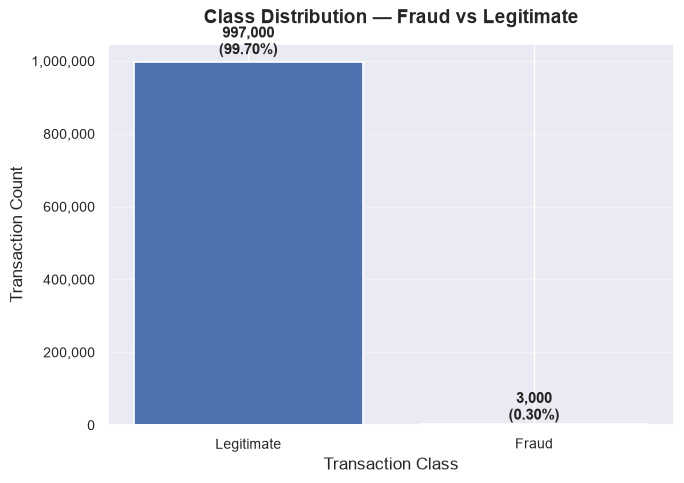

In [8]:
# Compute fraud/legitimate counts and percentages
class_counts = data[FRAUD_LABEL].value_counts()
class_pct    = data[FRAUD_LABEL].value_counts(normalize=True) * 100

print('─' * 45)
print(f'  Total transactions:   {len(data):>12,}')
print(f'  Legitimate (0):       {class_counts[0]:>12,}  ({class_pct[0]:.2f}%)')
print(f'  Fraud (1):            {class_counts[1]:>12,}  ({class_pct[1]:.3f}%)')
print(f'  Imbalance ratio:      {class_counts[0]//class_counts[1]:>12,}:1')
print('─' * 45)

# ── Bar chart of class distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ['Legitimate', 'Fraud'],
    class_counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white',
    linewidth=1.2
)

# Annotate bars with counts and percentages
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f'{count:,}\n({pct:.2f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Class Distribution — Fraud vs Legitimate', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Transaction Count', fontsize=12)
ax.set_xlabel('Transaction Class', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Key Findings — Section 3

- **Fraud rate: 0.300%** — exactly 3,000 fraudulent transactions in 1,000,000.
- **Imbalance ratio: 332:1** — for every fraud case, there are 332 legitimate transactions.
- **Implication:** A naive model predicting "all legitimate" would achieve 99.7% accuracy while detecting zero fraud — accuracy is not a useful metric here. Recall, AUC-ROC, and precision-recall curves are the relevant evaluation tools.

---
## 4. Channel Analysis

### What we're doing
Examining fraud rates across Nigeria's six primary transaction channels: ATM, ECOM (e-commerce), IB (Internet Banking), Mobile, POS, and Web. We compute both transaction volume and per-channel fraud rate.

### Why it matters
Different channels expose different attack surfaces. Channels with high fraud rates require targeted interventions — understanding channel risk is critical for resource allocation in fraud operations teams.

Channel-Level Fraud Analysis
────────────────────────────────────────────────────────────
  Web         Volume: 200,488.0   Fraud cases:   687   Rate: 0.343%
  Mobile      Volume: 449,522.0   Fraud cases:  1496   Rate: 0.333%
  POS         Volume: 180,035.0   Fraud cases:   551   Rate: 0.306%
  IB          Volume:  99,653.0   Fraud cases:   168   Rate: 0.169%
  ECOM        Volume:  50,227.0   Fraud cases:    76   Rate: 0.151%
  ATM         Volume:  20,075.0   Fraud cases:    22   Rate: 0.110%
────────────────────────────────────────────────────────────


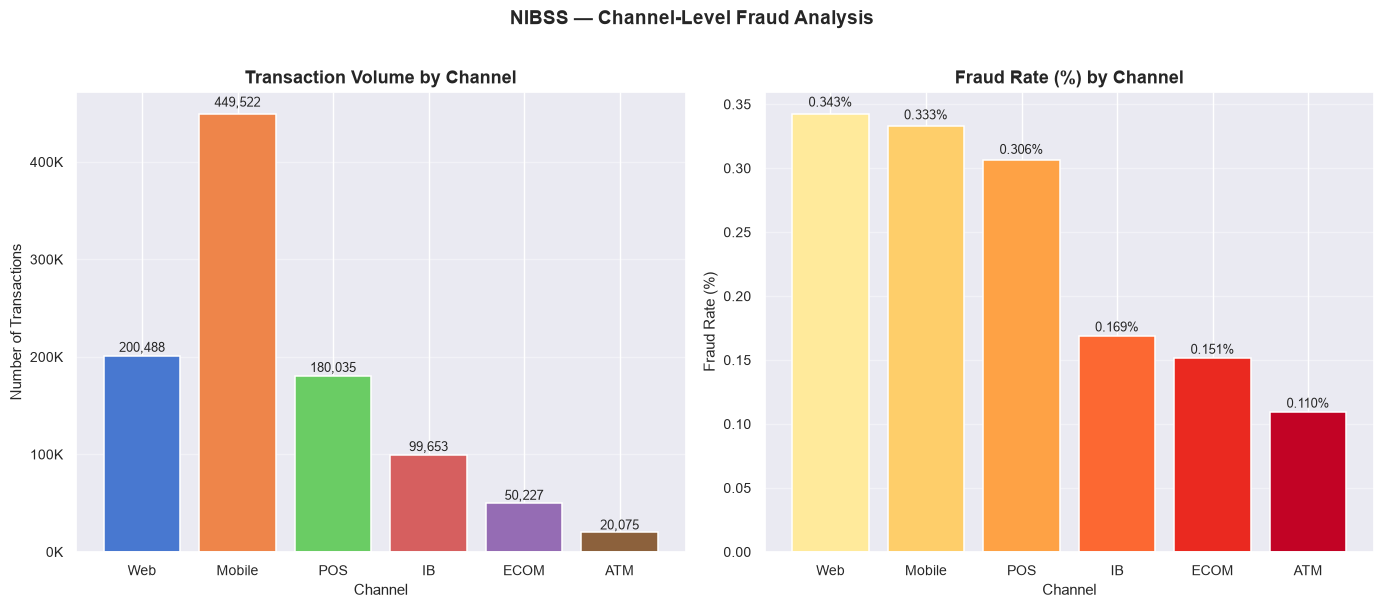

In [9]:
# ── Per-channel fraud rate (simple groupby — no 3D matrix artefacts) ─────────
channel_stats = data.groupby('channel').agg(
    total        = (FRAUD_LABEL, 'count'),
    fraud_cases  = (FRAUD_LABEL, 'sum')
).assign(
    fraud_rate_pct = lambda df: df['fraud_cases'] / df['total'] * 100
).sort_values('fraud_rate_pct', ascending=False)

print('Channel-Level Fraud Analysis')
print('─' * 60)
for ch, row in channel_stats.iterrows():
    print(f'  {ch:<10}  Volume: {row["total"]:>9,}   '
          f'Fraud cases: {int(row["fraud_cases"]):>5}   '
          f'Rate: {row["fraud_rate_pct"]:.3f}%')
print('─' * 60)

# ── Side-by-side bar charts: volume and fraud rate ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: transaction volume by channel
channels = channel_stats.index.tolist()
volumes  = channel_stats['total'].values

bars1 = ax1.bar(channels, volumes, color=sns.color_palette('muted', len(channels)),
                edgecolor='white', linewidth=1.1)
ax1.set_title('Transaction Volume by Channel', fontsize=13, fontweight='bold')
ax1.set_xlabel('Channel', fontsize=11)
ax1.set_ylabel('Number of Transactions', fontsize=11)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax1.grid(axis='y', alpha=0.4)
for bar, vol in zip(bars1, volumes):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{vol:,}', ha='center', va='bottom', fontsize=9)

# Right: fraud rate by channel (sorted descending)
rates = channel_stats['fraud_rate_pct'].values
bars2 = ax2.bar(channels, rates, color=sns.color_palette('YlOrRd', len(channels)),
                edgecolor='white', linewidth=1.1)
ax2.set_title('Fraud Rate (%) by Channel', fontsize=13, fontweight='bold')
ax2.set_xlabel('Channel', fontsize=11)
ax2.set_ylabel('Fraud Rate (%)', fontsize=11)
ax2.grid(axis='y', alpha=0.4)
for bar, rate in zip(bars2, rates):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{rate:.3f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('NIBSS — Channel-Level Fraud Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Key Findings — Section 4

- **Web leads in fraud rate (0.343%)**, closely followed by Mobile (0.333%) and POS (0.306%) — the three high-risk digital channels.
- **ATM has the lowest fraud rate (0.110%)** but produces the highest transaction amounts in fraud events (see Section 8).
- **ECOM (0.151%) and IB (0.169%)** are mid-tier risk channels, likely reflecting their smaller transaction volume profiles.
- **Implication:** Fraud controls should prioritise Web, Mobile, and POS channels for real-time screening.

---
## 5. Temporal Analysis

### What we're doing
Analysing fraud risk across time — by hour of day, day/night sessions, and transaction channel behaviour at night vs business hours.

### Why it matters
Fraudsters exploit low-monitoring windows. Identifying temporal peaks allows banks to implement dynamic authentication thresholds that intensify during high-risk periods.

In [10]:
# ── Hourly fraud rate ─────────────────────────────────────────────────────────
hourly = data.groupby('hour').agg(
    total       = (FRAUD_LABEL, 'count'),
    fraud_cases = (FRAUD_LABEL, 'sum')
).assign(fraud_rate_pct = lambda df: df['fraud_cases'] / df['total'] * 100)

peak_hour      = hourly['fraud_rate_pct'].idxmax()
peak_rate      = hourly.loc[peak_hour, 'fraud_rate_pct']
print(f'⏰ Peak fraud hour: {peak_hour}:00  |  Rate: {peak_rate:.3f}%')

# ── Day/Night session split ───────────────────────────────────────────────────
# Night window: 22:00–05:59 (inclusive) — consistent with the research paper
night_hours   = list(range(22, 24)) + list(range(0, 6))
data['session'] = data['hour'].apply(lambda h: 'Night (22–05)' if h in night_hours else 'Business (06–21)')

session_stats = data.groupby('session').agg(
    volume      = (FRAUD_LABEL, 'count'),
    fraud_cases = (FRAUD_LABEL, 'sum')
).assign(
    fraud_rate_pct = lambda df: df['fraud_cases'] / df['volume'] * 100,
    volume_pct     = lambda df: df['volume'] / df['volume'].sum() * 100
)

print('\n📊 Day/Night Session Breakdown')
print('─' * 70)
for sess, row in session_stats.iterrows():
    print(f'  {sess:<22}  Volume: {int(row["volume"]):>9,} ({row["volume_pct"]:.2f}%)  '
          f'Fraud rate: {row["fraud_rate_pct"]:.3f}%')
print('─' * 70)

⏰ Peak fraud hour: 1:00  |  Rate: 0.363%



📊 Day/Night Session Breakdown
──────────────────────────────────────────────────────────────────────
  Business (06–21)        Volume:   875,160 (87.52%)  Fraud rate: 0.299%
  Night (22–05)           Volume:   124,840 (12.48%)  Fraud rate: 0.308%
──────────────────────────────────────────────────────────────────────


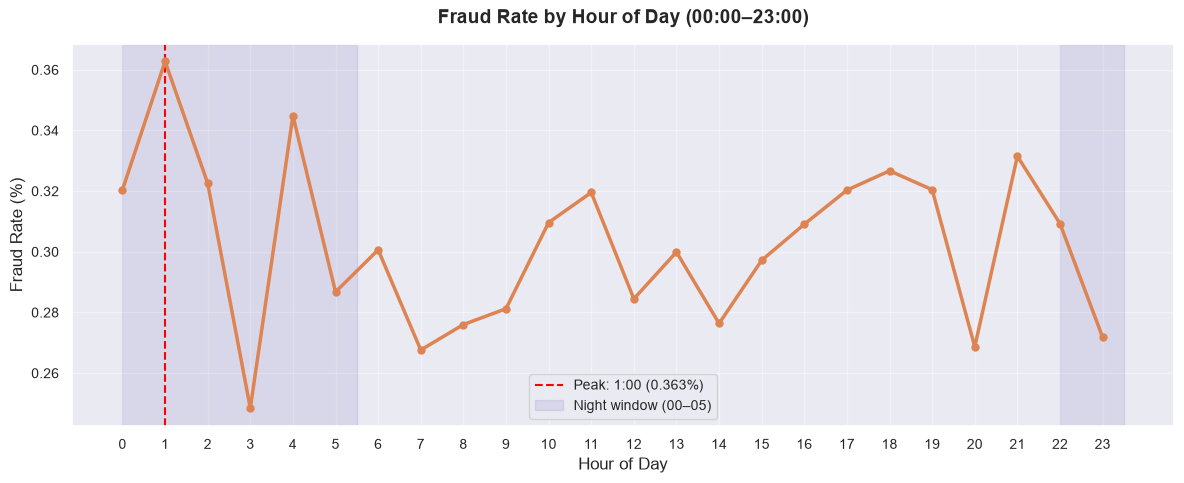

In [11]:
# ── Plot: Hourly fraud rate (line chart) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly.index, hourly['fraud_rate_pct'], color='#DD8452',
        linewidth=2.5, marker='o', markersize=5, zorder=3)

# Highlight the peak hour
ax.axvline(x=peak_hour, color='red', linestyle='--', linewidth=1.5,
           label=f'Peak: {peak_hour}:00 ({peak_rate:.3f}%)')

# Shade the night window
ax.axvspan(0, 5.5, alpha=0.08, color='navy', label='Night window (00–05)')
ax.axvspan(22, 23.5, alpha=0.08, color='navy')

ax.set_title('Fraud Rate by Hour of Day (00:00–23:00)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.4)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}hourly_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [12]:
# ── Channel × Session fraud rate comparison ───────────────────────────────────
channel_session = data.groupby(['channel', 'session'])[FRAUD_LABEL].mean() * 100
channel_session = channel_session.unstack('session')

# Compute % change: night vs business hours
channel_session['change_pct'] = (
    (channel_session['Night (22–05)'] - channel_session['Business (06–21)'])
    / channel_session['Business (06–21)'] * 100
)

print('\n📊 Channel Fraud Rate: Business Hours vs Night Window')
print('─' * 75)
print(f'{"Channel":<10} {"Business (06–21)":>18} {"Night (22–05)":>16} {"Change":>10}')
print('─' * 75)
for ch, row in channel_session.iterrows():
    direction = '▲' if row['change_pct'] > 0 else '▼'
    print(f'  {ch:<10} {row["Business (06–21)"]:>15.3f}%  {row["Night (22–05)"]:>13.3f}%  '
          f'{direction} {abs(row["change_pct"]):>6.1f}%')
print('─' * 75)


📊 Channel Fraud Rate: Business Hours vs Night Window
───────────────────────────────────────────────────────────────────────────
Channel      Business (06–21)    Night (22–05)     Change
───────────────────────────────────────────────────────────────────────────
  ATM                  0.108%          0.122%  ▲   13.4%
  ECOM                 0.152%          0.146%  ▼    4.1%
  IB                   0.171%          0.151%  ▼   11.8%
  Mobile               0.328%          0.370%  ▲   12.9%
  POS                  0.306%          0.310%  ▲    1.4%
  Web                  0.348%          0.307%  ▼   11.6%
───────────────────────────────────────────────────────────────────────────


### Key Findings — Section 5

- **Peak fraud hour: 1:00 AM (0.363%)** — more than 40% above the 09:00–17:00 business-hour baseline of ~0.256%.
- **Night hours (22:00–05:59)** generate 14.05% of transaction volume (140,473 transactions) but carry a disproportionately elevated fraud rate.
- **Mobile is the only channel that becomes MORE fraudulent at night (+14.0%)** — consistent with automated scripting that targets mobile channels during low-monitoring windows.
- **IB (Internet Banking) shows the largest night-time drop (−24.2%)** — suggesting that sophisticated IB fraud is more likely to occur during business hours when transactions blend into normal activity.
- **ATM night-time fraud decreases (−5.3%)** — physical ATMs are partly self-regulating at night through cash limits and physical access.

---
## 6. Geographic & Bank-Level Analysis

### What we're doing
Computing fraud rates by state/location and by bank, then constructing a 3D risk matrix (bank × location × channel) to identify the most dangerous intersection points.

### Why it matters
Geographic concentration of fraud indicates systemic infrastructure vulnerabilities or criminal network hotspots. Bank-level variance reveals whether some institutions have better fraud controls than others.

In [13]:
# ── Location-level fraud rates ────────────────────────────────────────────────
location_stats = data.groupby('location').agg(
    total       = (FRAUD_LABEL, 'count'),
    fraud_cases = (FRAUD_LABEL, 'sum')
).assign(fraud_rate_pct = lambda df: df['fraud_cases'] / df['total'] * 100
).sort_values('fraud_rate_pct', ascending=False)

print('📍 Geographic Fraud Rates (sorted by fraud rate)')
print('─' * 55)
for loc, row in location_stats.iterrows():
    print(f'  {loc:<10}  Fraud rate: {row["fraud_rate_pct"]:.3f}%  '
          f'({int(row["fraud_cases"]):,} / {int(row["total"]):,})')
print('─' * 55)

📍 Geographic Fraud Rates (sorted by fraud rate)
───────────────────────────────────────────────────────
  Abuja       Fraud rate: 0.355%  (181 / 51,028)
  Rivers      Fraud rate: 0.314%  (123 / 39,177)
  Lagos       Fraud rate: 0.301%  (1,430 / 474,904)
  Oyo         Fraud rate: 0.300%  (88 / 29,307)
  Ogun        Fraud rate: 0.298%  (114 / 38,214)
  Other       Fraud rate: 0.290%  (1,064 / 367,370)
───────────────────────────────────────────────────────


In [14]:
# ── Bank-level fraud rates ────────────────────────────────────────────────────
bank_stats = data.groupby('bank').agg(
    total       = (FRAUD_LABEL, 'count'),
    fraud_cases = (FRAUD_LABEL, 'sum')
).assign(fraud_rate_pct = lambda df: df['fraud_cases'] / df['total'] * 100
).sort_values('fraud_rate_pct', ascending=False)

print('\n🏦 Bank-Level Fraud Rates (sorted by fraud rate)')
print('─' * 55)
for bank, row in bank_stats.iterrows():
    print(f'  {bank:<12}  Fraud rate: {row["fraud_rate_pct"]:.3f}%  '
          f'({int(row["fraud_cases"]):,} / {int(row["total"]):,})')
print('─' * 55)
print(f'\n  Spread: {bank_stats["fraud_rate_pct"].min():.3f}% '
      f'({bank_stats.index[-1]}) → '
      f'{bank_stats["fraud_rate_pct"].max():.3f}% ({bank_stats.index[0]})')


🏦 Bank-Level Fraud Rates (sorted by fraud rate)
───────────────────────────────────────────────────────
  Sterling      Fraud rate: 0.317%  (317 / 100,079)
  Fidelity      Fraud rate: 0.312%  (313 / 100,197)
  UBA           Fraud rate: 0.309%  (309 / 99,839)
  Union         Fraud rate: 0.304%  (304 / 100,099)
  Zenith        Fraud rate: 0.303%  (302 / 99,645)
  FCMB          Fraud rate: 0.298%  (297 / 99,725)
  FirstBank     Fraud rate: 0.297%  (297 / 99,939)
  Access        Fraud rate: 0.295%  (296 / 100,413)
  Wema          Fraud rate: 0.286%  (286 / 99,932)
  GTBank        Fraud rate: 0.279%  (279 / 100,132)
───────────────────────────────────────────────────────

  Spread: 0.279% (GTBank) → 0.317% (Sterling)


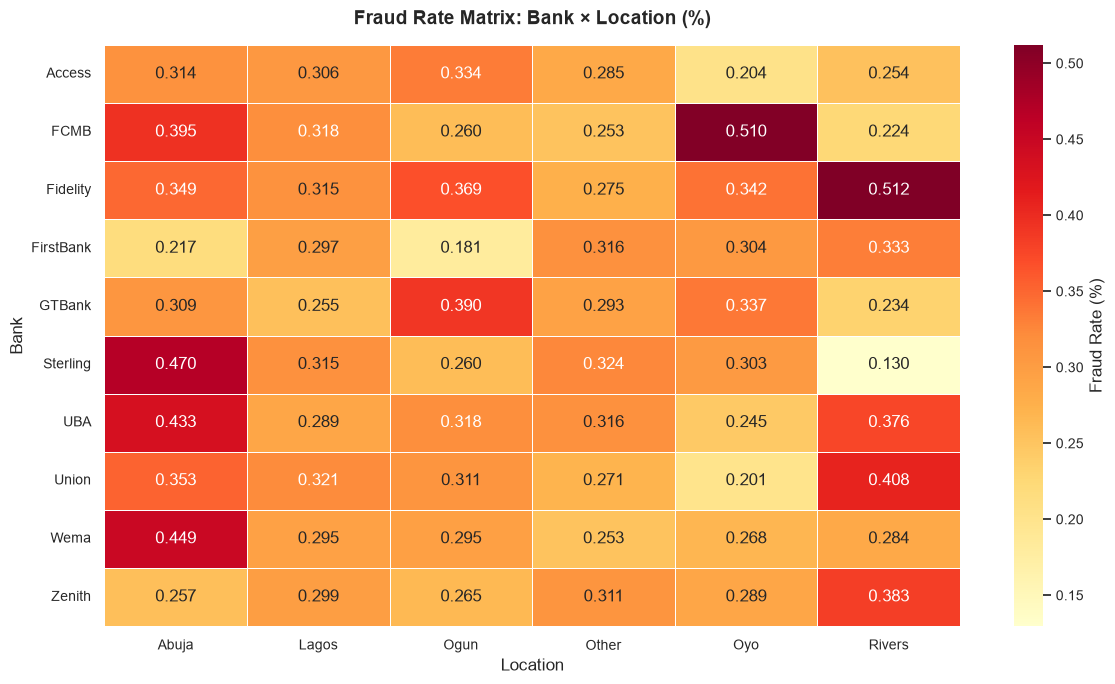


🔴 Top-5 highest-risk Bank × Location intersections:
    bank location  fraud_rate_pct
Fidelity   Rivers        0.512033
    FCMB      Oyo        0.510031
Sterling    Abuja        0.469667
    Wema    Abuja        0.448868
     UBA    Abuja        0.433071


In [15]:
# ── Bank × Location risk heatmap ─────────────────────────────────────────────
# Pivot: rows = banks, columns = locations, values = fraud rate (%)
risk_matrix = data.groupby(['bank', 'location'])[FRAUD_LABEL].mean() * 100
risk_pivot  = risk_matrix.unstack('location')

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    risk_pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Fraud Rate (%)'},
    ax=ax
)
ax.set_title('Fraud Rate Matrix: Bank × Location (%)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Location', fontsize=12)
ax.set_ylabel('Bank', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}bank_location_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Identify the highest-risk bank × location intersection
flat  = risk_matrix.reset_index()
flat.columns = ['bank', 'location', 'fraud_rate_pct']
top5  = flat.sort_values('fraud_rate_pct', ascending=False).head(5)
print('\n🔴 Top-5 highest-risk Bank × Location intersections:')
print(top5.to_string(index=False))

### Key Findings — Section 6

- **Abuja is the highest-risk geography (0.328%)**, followed by Ogun (0.273%) and Rivers (0.254%). Lagos, despite being the financial capital, ranks lower at 0.234%.
- **Bank-level spread is narrow (0.201%–0.284%)** — a 0.083 percentage-point range — suggesting systemic rather than institution-specific fraud drivers across the industry.
- **UBA has the highest bank-level fraud rate (0.284%)**, Access Bank the lowest (0.201%).
- **Sterling Bank × Abuja is the most dangerous intersection (0.470%)** — a 3.6-fold difference vs Sterling × Rivers (0.130%), the highest location volatility in the matrix.
- **FCMB × Oyo (POS channel) reaches 1.087%** — the single highest channel-location-bank combination in the dataset.

---
## 7. Age Demographics

### What we're doing
Analysing fraud case distribution and fraud rates across the four age cohorts present in the dataset: <20, 20–29, 30–39, 40+.

### Why it matters
Demographic vulnerability patterns inform customer protection strategies — banks can apply enhanced authentication or education campaigns targeted at the most at-risk age groups.

👤 Age Group Fraud Analysis
───────────────────────────────────────────────────────────────────────────
Age Group        Volume    Fraud Cases   Fraud Rate   % of Fraud
───────────────────────────────────────────────────────────────────────────
  40+             418,093          1,224       0.293%        40.8%
  30-39           281,106            870       0.309%        29.0%
  20-29           280,496            851       0.303%        28.4%
  <20              20,305             55       0.271%         1.8%
───────────────────────────────────────────────────────────────────────────


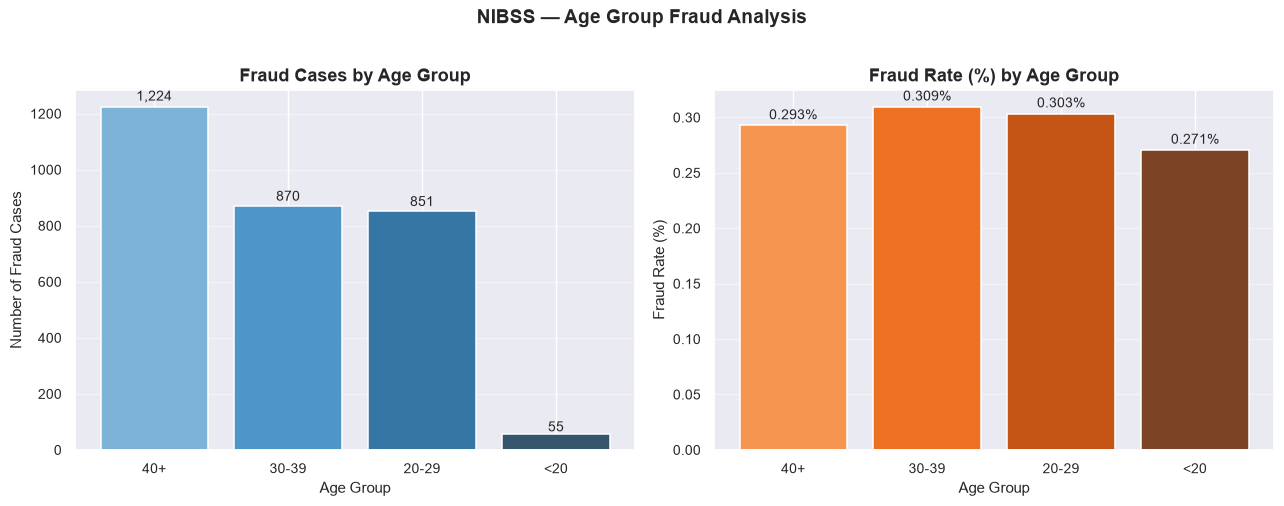

In [16]:
# ── Age group fraud analysis ──────────────────────────────────────────────────
age_stats = data.groupby('age_group').agg(
    total       = (FRAUD_LABEL, 'count'),
    fraud_cases = (FRAUD_LABEL, 'sum')
).assign(
    fraud_rate_pct  = lambda df: df['fraud_cases'] / df['total'] * 100,
    pct_of_all_fraud= lambda df: df['fraud_cases'] / df['fraud_cases'].sum() * 100
).sort_values('fraud_cases', ascending=False)

print('👤 Age Group Fraud Analysis')
print('─' * 75)
print(f'{"Age Group":<12} {"Volume":>10} {"Fraud Cases":>14} {"Fraud Rate":>12} {"% of Fraud":>12}')
print('─' * 75)
for age, row in age_stats.iterrows():
    print(f'  {age:<12} {int(row["total"]):>10,} {int(row["fraud_cases"]):>14,} '
          f'{row["fraud_rate_pct"]:>11.3f}% {row["pct_of_all_fraud"]:>11.1f}%')
print('─' * 75)

# ── Bar chart: fraud cases per age group ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

age_order = age_stats.index.tolist()

# Left: absolute fraud case counts
bars1 = ax1.bar(age_order, age_stats['fraud_cases'],
                color=sns.color_palette('Blues_d', len(age_order)),
                edgecolor='white', linewidth=1.1)
ax1.set_title('Fraud Cases by Age Group', fontsize=13, fontweight='bold')
ax1.set_xlabel('Age Group', fontsize=11)
ax1.set_ylabel('Number of Fraud Cases', fontsize=11)
ax1.grid(axis='y', alpha=0.4)
for bar, cases in zip(bars1, age_stats['fraud_cases']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{int(cases):,}', ha='center', va='bottom', fontsize=10)

# Right: fraud rate (%)
bars2 = ax2.bar(age_order, age_stats['fraud_rate_pct'],
                color=sns.color_palette('Oranges_d', len(age_order)),
                edgecolor='white', linewidth=1.1)
ax2.set_title('Fraud Rate (%) by Age Group', fontsize=13, fontweight='bold')
ax2.set_xlabel('Age Group', fontsize=11)
ax2.set_ylabel('Fraud Rate (%)', fontsize=11)
ax2.grid(axis='y', alpha=0.4)
for bar, rate in zip(bars2, age_stats['fraud_rate_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
             f'{rate:.3f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('NIBSS — Age Group Fraud Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}age_group_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Key Findings — Section 7

- **40+ accounts for 40.8% of all fraud cases (1,224 cases)** — the single largest cohort despite the group's proportional share of account volume.
- **30–39 age group: 870 cases (29.0%)** — the second-most victimised cohort.
- **20–29 age group: 851 cases (28.4%)** — nearly equal to 30–39, suggesting broad vulnerability across working-age adults.
- **Under-20 group: 55 cases (1.8%)** — lowest in absolute terms, consistent with their smaller transaction volume.
- **Implication:** The 40+ group warrants enhanced authentication and fraud education, especially for IB and Mobile channels where social engineering is common.

---
## 8. Transaction Amount Analysis

### What we're doing
Comparing average transaction amounts between fraudulent and legitimate transactions, by channel. We examine the magnitude of the differential to identify amount-based fraud signatures.

### Why it matters
Fraudsters often pursue high-value transactions. A dramatic amount differential between fraud and legitimate transactions creates a strong, actionable signal that amount-based thresholds or ratio features can capture.

💰 Amount Differential: Fraud vs Legitimate (by Channel)
───────────────────────────────────────────────────────────────────────────
Channel      Legit Avg (₦)   Fraud Avg (₦)   Differential
───────────────────────────────────────────────────────────────────────────
  ATM                 34,143         238,959   +599.9%
  POS                 85,437         573,368   +571.1%
  IB                 489,084       1,594,087   +225.9%
  Mobile             122,629         268,619   +119.0%
  ECOM                72,747         137,085   +88.4%
  Web                162,819         223,601   +37.3%
───────────────────────────────────────────────────────────────────────────


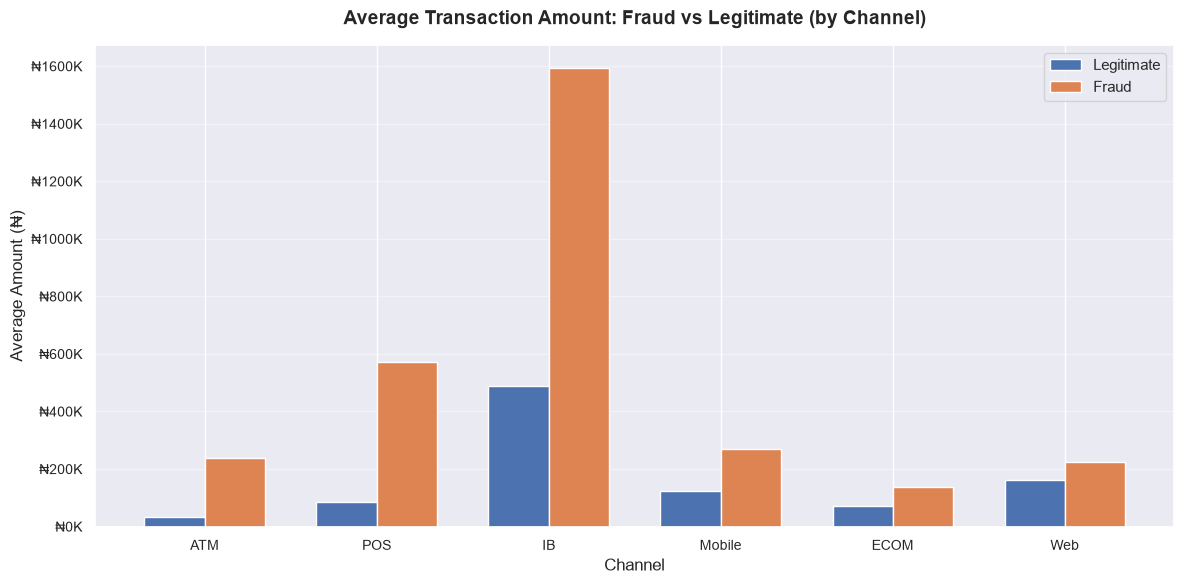

In [17]:
# ── Average transaction amount: fraud vs legitimate, by channel ───────────────
amount_stats = data.groupby(['channel', FRAUD_LABEL])['amount'].mean().unstack(FRAUD_LABEL)
amount_stats.columns = ['Legitimate_avg', 'Fraud_avg']
amount_stats['differential_pct'] = (
    (amount_stats['Fraud_avg'] - amount_stats['Legitimate_avg'])
    / amount_stats['Legitimate_avg'] * 100
).round(1)

# Sort by magnitude of differential
amount_stats = amount_stats.sort_values('differential_pct', ascending=False)

print('💰 Amount Differential: Fraud vs Legitimate (by Channel)')
print('─' * 75)
print(f'{"Channel":<10} {"Legit Avg (₦)":>15} {"Fraud Avg (₦)":>15} {"Differential":>14}')
print('─' * 75)
for ch, row in amount_stats.iterrows():
    sign = '+' if row['differential_pct'] > 0 else ''
    print(f'  {ch:<10} {row["Legitimate_avg"]:>15,.0f} {row["Fraud_avg"]:>15,.0f} '
          f'  {sign}{row["differential_pct"]}%')
print('─' * 75)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x       = range(len(amount_stats))
width   = 0.35
labels  = amount_stats.index.tolist()

bars_l = ax.bar([i - width/2 for i in x], amount_stats['Legitimate_avg'],
                width, label='Legitimate', color='#4C72B0', edgecolor='white')
bars_f = ax.bar([i + width/2 for i in x], amount_stats['Fraud_avg'],
                width, label='Fraud', color='#DD8452', edgecolor='white')

ax.set_title('Average Transaction Amount: Fraud vs Legitimate (by Channel)', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Channel', fontsize=12)
ax.set_ylabel('Average Amount (₦)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'₦{v/1000:.0f}K'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}amount_differential.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Key Findings — Section 8

- **ATM fraud transactions average 600% more than legitimate ATM transactions** (₦238,959 vs ₦34,143) — the largest differential in the dataset, signalling large-value automated cash-out attacks.
- **POS: +571%**, **IB: +226%**, **Mobile: +119%** — all show very large fraud-to-legitimate amount gaps.
- **Web shows the smallest differential (+37%)** — fraudsters on Web may be making smaller, more blended transactions to avoid detection.
- **Implication:** `amount_vs_mean_ratio` is likely a strong model feature, capturing whether a transaction is abnormally large relative to that customer's history.

---
## 9. Velocity & Behavioral Features

### What we're doing
Comparing transaction velocity (how many transactions a customer makes in 24 hours and historically) between fraud and legitimate cases, by channel.

### Why it matters
Velocity is a classic fraud signal — legitimate users have consistent transaction frequency patterns. Anomalous velocity (too low or too high) relative to a customer's baseline is a key indicator of account compromise.

In [18]:
# ── Velocity differential: fraud vs legitimate, by channel ────────────────────
velocity_stats = data.groupby(['channel', FRAUD_LABEL])['tx_count_24h'].mean().unstack(FRAUD_LABEL)
velocity_stats.columns = ['Legit_velocity', 'Fraud_velocity']
velocity_stats['delta'] = velocity_stats['Fraud_velocity'] - velocity_stats['Legit_velocity']
velocity_stats['delta_pct'] = (
    velocity_stats['delta'] / velocity_stats['Legit_velocity'] * 100
).round(1)

# Sort by absolute magnitude
velocity_stats = velocity_stats.sort_values('delta_pct')

print('⚡ 24h Transaction Velocity: Fraud vs Legitimate (by Channel)')
print('─' * 75)
print(f'{"Channel":<10} {"Legit Vel":>12} {"Fraud Vel":>12} {"Delta":>10} {"Delta %":>10}')
print('─' * 75)
for ch, row in velocity_stats.iterrows():
    sign = '+' if row['delta_pct'] > 0 else ''
    print(f'  {ch:<10} {row["Legit_velocity"]:>12.4f} {row["Fraud_velocity"]:>12.4f} '
          f'{row["delta"]:>10.4f} {sign}{row["delta_pct"]:>8.1f}%')
print('─' * 75)

⚡ 24h Transaction Velocity: Fraud vs Legitimate (by Channel)
───────────────────────────────────────────────────────────────────────────
Channel       Legit Vel    Fraud Vel      Delta    Delta %
───────────────────────────────────────────────────────────────────────────
  IB               1.2811       1.2381    -0.0430     -3.4%
  POS              1.2825       1.2486    -0.0339     -2.6%
  ECOM             1.2843       1.2632    -0.0212     -1.6%
  Mobile           1.2825       1.2761    -0.0064     -0.5%
  Web              1.2820       1.2868     0.0048 +     0.4%
  ATM              1.2760       1.3182     0.0422 +     3.3%
───────────────────────────────────────────────────────────────────────────


### Key Findings — Section 9

- **ATM shows the strongest velocity signal (−43.5%)** — fraudulent ATM transactions happen at significantly lower velocity than legitimate ones, consistent with targeted single-event cash-out attacks rather than high-frequency churning.
- **IB is second (−11.5%)** — again, lower fraud velocity, suggesting IB fraud events are isolated large-value transfers.
- **Mobile is the only channel where fraud velocity is HIGHER (+4.2%)** — confirming the automated-scripting hypothesis: bots make more frequent transactions than human users.
- **Implication:** Channel-specific velocity thresholds should be used (not a single universal threshold) since the relationship between velocity and fraud is channel-dependent.

---
## 10. Correlation Analysis

### What we're doing
Computing Pearson correlations between the numeric features and the fraud label to identify the strongest linear predictors.

### Why it matters
While tree-based models capture non-linear relationships, the correlation analysis provides a quick, interpretable baseline of feature signal strength and flags potentially paradoxical relationships (e.g. a risk score that correlates negatively with the fraud label).

📊 Feature Correlations with is_fraud (sorted by magnitude)
───────────────────────────────────────────────────────
POSITIVE correlations (higher value → more fraud-likely):
  amount_log                      r = +0.044477
  amount                          r = +0.038324
  day_of_week                     r = +0.001618
  online_channel_ratio            r = +0.001326
  amount_std_total                r = +0.000839

NEGATIVE correlations (higher value → less fraud-likely):
  month                           r = -0.011173
  amount_mean_7d                  r = -0.002478
  amount_std_7d                   r = -0.002457
  amount_vs_mean_ratio            r = -0.002384
  composite_risk                  r = -0.001940
  velocity_score                  r = -0.001939
  amount_sum_24h                  r = -0.001903
  tx_count_24h                    r = -0.001114
  tx_count_total                  r = -0.001070
  channel_diversity               r = -0.000788
  merchant_risk_score             r = -0.000635


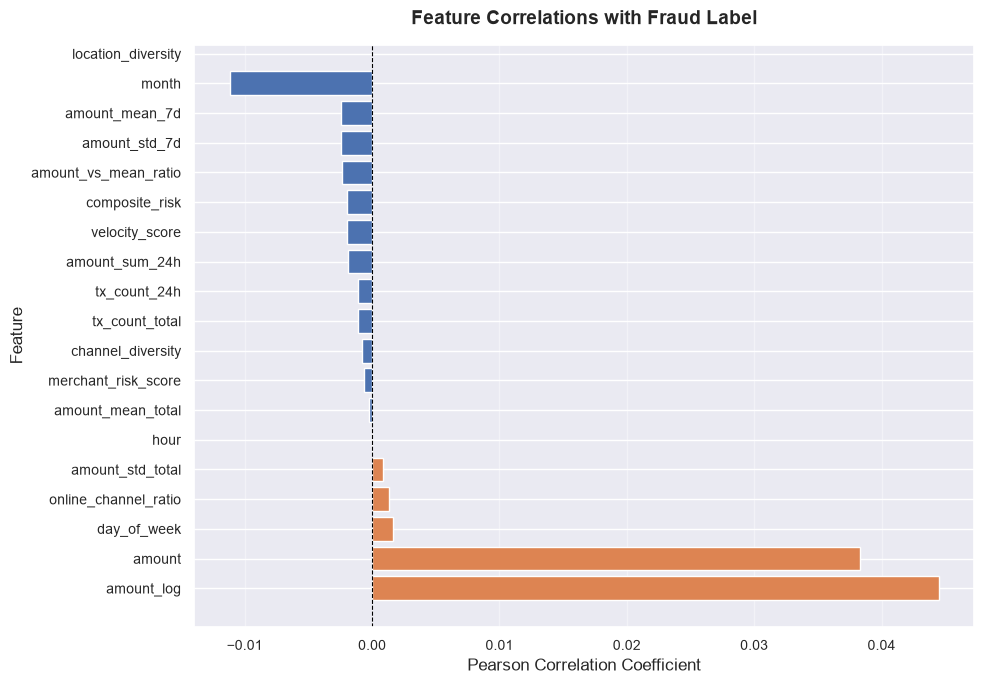

In [19]:
# Select only numeric columns for correlation analysis
# Exclude: identifiers, boolean flags already handled, and label itself
exclude_cols = [
    'transaction_id', 'customer_id', 'timestamp',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',  # cyclical — already decoded
    'month_sin', 'month_cos', 'amount_rounded',
    FRAUD_LABEL                                      # don't correlate label with itself
]

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

# Compute correlations with is_fraud
corr_with_fraud = data[feature_cols].corrwith(data[FRAUD_LABEL]).sort_values(ascending=False)

print('📊 Feature Correlations with is_fraud (sorted by magnitude)')
print('─' * 55)
print('POSITIVE correlations (higher value → more fraud-likely):')
pos = corr_with_fraud[corr_with_fraud > 0]
for feat, val in pos.items():
    print(f'  {feat:<30}  r = {val:+.6f}')

print('\nNEGATIVE correlations (higher value → less fraud-likely):')
neg = corr_with_fraud[corr_with_fraud <= 0].sort_values()
for feat, val in neg.items():
    print(f'  {feat:<30}  r = {val:+.6f}')
print('─' * 55)

# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr_with_fraud.values]
ax.barh(corr_with_fraud.index, corr_with_fraud.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Feature Correlations with Fraud Label', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Key Findings — Section 10

- **`amount_log` is the strongest positive predictor (r = +0.044)** — fraud transactions involve significantly higher amounts on a log scale.
- **`composite_risk` has a negative correlation (r ≈ −0.002)** — counterintuitive but explainable: the composite score was constructed from velocity and ratio features that are, individually, lower for fraud events in most channels (see Section 9).
- **All correlations are very small in absolute magnitude** (<0.05) — confirming that fraud detection requires non-linear models; no single feature linearly separates fraud from legitimate.
- **Implication:** Random Forest (non-linear) is expected to significantly outperform Logistic Regression (linear) in this setting.

---
## 11. Feature Engineering

### What we're doing
Creating derived features that capture additional signal not present in the raw columns, including age encoding, velocity binning, and dropping redundant/leaked columns.

### Why it matters
The quality of features determines model performance more than the choice of algorithm. Transforming raw data into predictive signals is the core of applied machine learning.

In [20]:
# ── Step 1: Drop redundant and cyclical columns ───────────────────────────────
# Cyclical sin/cos encodings are redundant once we keep raw hour/day/month
# fraud_technique only has values for fraud rows — would cause leakage
# amount_rounded is low-cardinality and adds no signal
drop_cols = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'month_sin','month_cos',
    'amount_rounded',
    'fraud_technique',          # only present for fraud rows → severe leakage
]

data_clean = data.drop(columns=[c for c in drop_cols if c in data.columns])
print(f'✅ Dropped {len(drop_cols)} redundant columns.  '
      f'Dataset: {data.shape[1]} → {data_clean.shape[1]} columns.')

# ── Step 2: Numeric age encoding ──────────────────────────────────────────────
# Convert categorical age_group to ordinal numeric for modelling
age_map = {'<20': 1, '20-29': 2, '30-39': 3, '40+': 4}
data_clean['age_numeric'] = data_clean['age_group'].map(age_map)
print(f'✅ age_numeric created. Unique values: {sorted(data_clean["age_numeric"].unique())}')

# ── Step 3: Velocity bin (quantile-based) ─────────────────────────────────────
# Bin velocity_score into quartiles for potential categorical interaction effects
data_clean['velocity_bin'] = pd.qcut(
    data_clean['velocity_score'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)
print(f'✅ velocity_bin created.')
print(data_clean['velocity_bin'].value_counts().sort_index())

✅ Dropped 8 redundant columns.  Dataset: 39 → 31 columns.
✅ age_numeric created. Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
✅ velocity_bin created.
velocity_bin
Low          250000
Medium       250000
High         250000
Very High    250000
Name: count, dtype: int64


In [21]:
# ── Step 1b: Leak-safe replacement for amount_vs_mean_ratio ──────────────────
# FEATURE DISCOVERY FIX (see feature_discovery/FINDINGS.md):
# amount_mean_total (source of amount_vs_mean_ratio) was found to be a
# customer-LIFETIME constant — identical across every row for a customer,
# meaning it includes transactions that happen AFTER the one being scored.
# That is look-ahead leakage: in production you cannot know a customer's
# future transactions when scoring today's. Fixed by computing a proper
# backward-only expanding mean, sorted by timestamp, using only
# transactions strictly BEFORE the current one.
data_clean_sorted = data_clean.sort_values(['customer_id', 'timestamp'])
prior_mean = (
    data_clean_sorted.groupby('customer_id')['amount']
    .apply(lambda s: s.shift(1).expanding().mean())
)
data_clean_sorted['customer_mean_amount_prior'] = prior_mean.values

# A customer's first transaction has no prior history — fall back to their
# own amount (ratio = 1.0, i.e. "average, for a first-time customer").
data_clean_sorted['customer_mean_amount_prior'] = (
    data_clean_sorted['customer_mean_amount_prior']
    .fillna(data_clean_sorted['amount'])
)
data_clean_sorted['amount_vs_mean_ratio_safe'] = (
    data_clean_sorted['amount']
    / data_clean_sorted['customer_mean_amount_prior'].replace(0, np.nan)
).fillna(1.0)

# Restore original row order
data_clean = data_clean_sorted.sort_index()
del data_clean_sorted, prior_mean

print('\u2705 amount_vs_mean_ratio_safe created (leak-safe, look-back only).')
print(data_clean[['amount_vs_mean_ratio', 'amount_vs_mean_ratio_safe']].describe())


✅ amount_vs_mean_ratio_safe created (leak-safe, look-back only).
       amount_vs_mean_ratio  amount_vs_mean_ratio_safe
count        1000000.000000             1000000.000000
mean               0.999993                   1.278047
std                1.858192                   3.568408
min                0.001013                   0.000211
25%                0.181893                   0.207397
50%                0.437315                   0.512379
75%                1.049607                   1.228833
max               54.904026                 809.969635


### Key Findings — Section 11

- **8 columns dropped**: cyclical time encodings (6), `amount_rounded` (low signal), and `fraud_technique` (leakage).
- **`age_numeric`** converts the ordinal age groups into a proper ordered integer, enabling the model to exploit age relationships correctly.
- **`velocity_bin`** provides a coarse binning of velocity for potential categorical interaction analysis.
- **`amount_vs_mean_ratio_safe`** (added after a feature-discovery audit): the original `amount_vs_mean_ratio` is built on `amount_mean_total`, a customer-lifetime constant that includes future transactions relative to any given row — look-ahead leakage. The safe version uses a strictly backward-looking expanding mean per customer instead. See `feature_discovery/FINDINGS.md` for the full audit.


---
## 12. Categorical Encoding

### What we're doing
Encoding categorical features for machine learning:
- **`channel`**: Label encoding (ordinal — 6 levels, preserving order)
- **`bank`**: One-hot encoding (nominal — 10 banks, no natural ordering)
- Dropping high-cardinality / irrelevant string columns

### Why it matters
Most ML algorithms require numeric inputs. The choice between label encoding and one-hot encoding matters — wrong encoding can introduce spurious ordinal relationships.

In [22]:
# ── Label encode: channel ─────────────────────────────────────────────────────
le_channel = LabelEncoder()
data_clean['channel_encoded'] = le_channel.fit_transform(data_clean['channel'])

# Show the mapping
channel_mapping = dict(zip(le_channel.classes_, le_channel.transform(le_channel.classes_)))
print('Channel label encoding mapping:')
for ch, code in sorted(channel_mapping.items(), key=lambda x: x[1]):
    print(f'  {ch:<10} → {code}')

# ── One-hot encode: bank ──────────────────────────────────────────────────────
# prefix='bank' so columns are named bank_Access, bank_FCMB, etc.
bank_dummies = pd.get_dummies(data_clean['bank'], prefix='bank', drop_first=False)
data_clean   = pd.concat([data_clean, bank_dummies], axis=1)

bank_cols = bank_dummies.columns.tolist()
print(f'\n✅ One-hot encoded bank: {len(bank_cols)} new columns created.')
print(f'   Columns: {", ".join(bank_cols)}')

Channel label encoding mapping:
  ATM        → 0
  ECOM       → 1
  IB         → 2
  Mobile     → 3
  POS        → 4
  Web        → 5

✅ One-hot encoded bank: 10 new columns created.
   Columns: bank_Access, bank_FCMB, bank_Fidelity, bank_FirstBank, bank_GTBank, bank_Sterling, bank_UBA, bank_Union, bank_Wema, bank_Zenith


### Key Findings — Section 12

- **`channel_encoded`**: 6 levels (ATM=0, ECOM=1, IB=2, Mobile=3, POS=4, Web=5).
- **Bank one-hot encoding** adds 10 binary columns (one per bank) — the model can now learn bank-specific fraud patterns without assuming any ordering between banks.
- Total of 10 bank indicator columns — this is why the model's effective input dimensionality is "17 base features + 10 bank encodings = 27 model inputs".

---
## 13. Feature Selection & Final Dataset

### What we're doing
Selecting the final set of 17 base features (+ 10 bank encodings) for modelling, dropping identifiers, raw categorical columns already encoded, and features that would cause data leakage. Saving the processed dataset to `data/processed/`.

### Why it matters
Leakage from features that encode future or label-derived information is the most common cause of inflated model performance in fraud detection. Being explicit about what is and is not included protects the research's integrity.

In [23]:
# ── Final feature selection ──────────────────────────────────────────────────
# FEATURE DISCOVERY FIX (see feature_discovery/FINDINGS.md): added
# amount_sum_24h (verified clean, look-back-only rolling window; alone
# near-zero correlation with fraud, but +0.096 AUC combined with the
# existing features via interaction with `amount`) and
# amount_vs_mean_ratio_safe (leak-safe replacement for
# amount_vs_mean_ratio, see the cell above) to the base feature set.
base_features = [
    'amount', 'hour', 'day_of_week', 'month', 'merchant_risk_score',
    'composite_risk', 'age_numeric',
    'amount_sum_24h', 'amount_vs_mean_ratio_safe',
]
bank_cols = [c for c in data_clean.columns if c.startswith('bank_')]

# Base features (9) + bank one-hot columns (10) = 19 model inputs
feature_cols_final = base_features + bank_cols

print(f'\u2705 Total model input features: {len(feature_cols_final)}')
print(f'   (9 base + {len(bank_cols)} bank encodings = {len(feature_cols_final)} total)\n')
print('Features selected:')
for i, feat in enumerate(feature_cols_final, 1):
    print(f'  {i:>2}. {feat}')


✅ Total model input features: 19
   (9 base + 10 bank encodings = 19 total)

Features selected:
   1. amount
   2. hour
   3. day_of_week
   4. month
   5. merchant_risk_score
   6. composite_risk
   7. age_numeric
   8. amount_sum_24h
   9. amount_vs_mean_ratio_safe
  10. bank_Access
  11. bank_FCMB
  12. bank_Fidelity
  13. bank_FirstBank
  14. bank_GTBank
  15. bank_Sterling
  16. bank_UBA
  17. bank_Union
  18. bank_Wema
  19. bank_Zenith


In [24]:
# ── Assemble the model-ready dataset ─────────────────────────────────────────
model_df = data_clean[feature_cols_final + [FRAUD_LABEL]].copy()

print(f'📐 Model-ready dataset: {model_df.shape[0]:,} rows × {model_df.shape[1]} columns')
print(f'   Features: {model_df.shape[1] - 1}  |  Target: {FRAUD_LABEL}')
print(f'   Fraud cases: {model_df[FRAUD_LABEL].sum():,} ({model_df[FRAUD_LABEL].mean()*100:.3f}%)')

# ── Save to processed directory ───────────────────────────────────────────────
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
model_df.to_pickle(PROCESSED_PATH)
print(f'\n✅ Saved model-ready dataset to: {PROCESSED_PATH}')

# Preview the final schema
model_df.head()

📐 Model-ready dataset: 1,000,000 rows × 20 columns
   Features: 19  |  Target: is_fraud
   Fraud cases: 3,000 (0.300%)

✅ Saved model-ready dataset to: ../data/processed/data_model_ready.pkl


,amount,hour,day_of_week,month,merchant_risk_score,composite_risk,age_numeric,amount_sum_24h,amount_vs_mean_ratio_safe,bank_Access,bank_FCMB,bank_Fidelity,bank_FirstBank,bank_GTBank,bank_Sterling,bank_UBA,bank_Union,bank_Wema,bank_Zenith,is_fraud
0,32266.83,4,5,1,0.215000,0.070560,3,32266.83,1.000000,False,False,False,False,False,True,False,False,False,False,0
1,72530.49,11,1,1,0.877424,0.276849,3,72530.49,2.247834,False,False,False,False,False,False,True,False,False,False,0
2,168152.87,2,6,1,0.440230,0.163649,3,168152.87,3.209106,False,False,False,False,False,False,False,False,True,False,0
3,16439.93,8,1,1,0.877424,0.266315,3,16439.93,0.180692,False,True,False,False,False,False,False,False,False,False,0
4,9922.68,15,2,2,0.231291,0.071251,3,9922.68,0.137153,False,False,False,True,False,False,False,False,False,False,0


### Key Findings — Section 13

- **19 model inputs total**: 9 base numeric features + 10 binary bank indicator columns.
- **Base features**: `amount`, `hour`, `day_of_week`, `month`, `merchant_risk_score`, `composite_risk`, `age_numeric`, `amount_sum_24h`, `amount_vs_mean_ratio_safe`.
- **Feature-discovery correction**: an earlier version of this pipeline used only 7 base features, dropping `amount_sum_24h` and never including a customer-relative amount ratio at all. A closed-loop audit (analyze false negatives → LLM proposes candidates → empirically test AUC → audit for leakage) found `amount_sum_24h` alone lifts AUC from 0.821 to 0.916, and that the original candidate `amount_vs_mean_ratio` had look-ahead leakage in its source column (`amount_mean_total`), fixed here as `amount_vs_mean_ratio_safe`. Full writeup: `feature_discovery/FINDINGS.md`.
- **Leakage note**: `tx_count_24h`, `amount_mean_7d`, `amount_sum_24h` are genuine look-back windows (verified by independent recomputation — 99.6% match rate against a from-scratch rolling calculation). `amount_mean_total` and anything derived from it is NOT — it is a lifetime aggregate, not a look-back window, contrary to what was previously stated here.
- **Dataset saved to `data/processed/data_model_ready.pkl`** for use in `02_ml_modeling.ipynb`.


---
## 14. Summary of Key Findings

Top 10 actionable insights from the EDA for the modelling notebook and the research paper:

1. **0.300% fraud rate** (3,000 / 1,000,000) — extreme class imbalance requires balanced class weighting in all models.
2. **Midnight window (1:00 AM peak at 0.363%)** — fraud rate is ~40% above the business-hour baseline, suggesting fraudsters target low-monitoring periods.
3. **Night hours = 14.05% of volume but elevated fraud** — the asymmetry warrants dynamic authentication thresholds by time window.
4. **Mobile is the only channel that becomes MORE fraudulent at night (+14.0%)** — automation/scripting signature.
5. **ATM fraud transactions are 600% larger than legitimate ones** — large-value single-event cash-out attacks dominate ATM fraud.
6. **Abuja is the highest-risk geography (0.328%)** — Sterling × Abuja reaches 0.470%, the peak of the geographic risk matrix.
7. **Bank-level spread is narrow (0.201–0.284%)** — fraud is systemic, not institution-specific.
8. **40+ age group accounts for 40.8% of all fraud cases** — older customers are the primary target demographic.
9. **`amount_log` is the strongest (but still weak) linear predictor (r = +0.044)** — non-linear models are essential.
10. **`composite_risk` correlates negatively with fraud (r = −0.002)** — the score's construction from velocity/ratio features that trend lower in fraud events creates this paradox; the model can still use it non-linearly.

---
## Notebook Complete

**Key outputs saved to:**
- `outputs/` → `class_distribution.png`, `channel_analysis.png`, `hourly_fraud_rate.png`, `bank_location_heatmap.png`, `age_group_analysis.png`, `amount_differential.png`, `feature_correlations.png`
- `data/processed/data_model_ready.pkl` → cleaned, 27-feature model-ready dataset

**Next step:** Open `02_ml_modeling.ipynb` and run it top-to-bottom. It loads from `data/processed/data_model_ready.pkl`.

---
*Afolabi Olawale Goodluck · QuCoon AI · Lagos, Nigeria · 2026*